In [1]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

NumPy: 2.5.2
Pandas: 2.2.3


In [2]:
df = pd.read_csv("diabetes_data.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (3000, 36)


,Unnamed: 0,Fasting_Blood_Glucose,Postprandial_Blood_Glucose,HbA1c,Random_Blood_Glucose,BMI,Waist_Circumference,Triglyceride_Levels,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,...,Gestational_Diabetes,PCOS,Hypertension,Physical_Activity,Smoking,Alcohol_Consumption,Obesity,Diet,Sleep_Apnea,Diabetes_Status
0,0,118.690215,111.472598,5.570234,224.721689,29.299897,37.872710,212.064239,93.491951,100.418755,...,Yes,No,Yes,Yes,No,Yes,No,No,No,Positive
1,1,193.592860,172.123161,5.481873,253.236721,35.135808,39.468713,93.096591,106.809528,98.109810,...,Yes,No,No,No,Yes,No,No,Yes,No,Negative
2,2,165.159212,228.400792,9.437527,127.607617,34.004023,47.090948,268.098641,164.812122,56.702794,...,No,No,No,Yes,Yes,No,Yes,No,No,Positive
3,3,147.825603,204.478231,5.497277,213.721043,18.847498,36.800088,203.279060,159.009152,114.580068,...,Yes,Yes,Yes,No,No,Yes,No,No,Yes,Positive
4,4,90.282423,217.115395,5.631698,201.501576,18.731237,47.392994,89.300971,121.557842,89.793054,...,Yes,Yes,No,Yes,No,Yes,No,Yes,Yes,Positive


In [3]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Rows and columns: (3000, 36)

Column names:
['Unnamed: 0', 'Fasting_Blood_Glucose', 'Postprandial_Blood_Glucose', 'HbA1c', 'Random_Blood_Glucose', 'BMI', 'Waist_Circumference', 'Triglyceride_Levels', 'Blood_Pressure_Systolic', 'Blood_Pressure_Diastolic', 'LDL_Cholesterol', 'HDL_Cholesterol', 'CRP_Levels', 'Insulin_Levels', 'HOMA_IR', 'OGTT', 'Creatinine_Levels', 'eGFR', 'Microalbuminuria', 'Uric_Acid_Levels', 'Fructosamine_Levels', 'ALT', 'AST', 'C_Peptide', 'Proinsulin_Levels', 'Family_History_of_Diabetes', 'Gestational_Diabetes', 'PCOS', 'Hypertension', 'Physical_Activity', 'Smoking', 'Alcohol_Consumption', 'Obesity', 'Diet', 'Sleep_Apnea', 'Diabetes_Status']

Data types:
Unnamed: 0                      int64
Fasting_Blood_Glucose         float64
Postprandial_Blood_Glucose    float64
HbA1c                         float64
Random_Blood_Glucose          float64
BMI                           float64
Waist_Circumference           float64
Triglyceride_Levels           float64
Blood_Pressur

In [4]:
df = df.drop(columns=["Unnamed: 0"])

print("New shape:", df.shape)
print(df.head())

New shape: (3000, 35)
   Fasting_Blood_Glucose  Postprandial_Blood_Glucose     HbA1c  \
0             118.690215                  111.472598  5.570234   
1             193.592860                  172.123161  5.481873   
2             165.159212                  228.400792  9.437527   
3             147.825603                  204.478231  5.497277   
4              90.282423                  217.115395  5.631698   

   Random_Blood_Glucose        BMI  Waist_Circumference  Triglyceride_Levels  \
0            224.721689  29.299897            37.872710           212.064239   
1            253.236721  35.135808            39.468713            93.096591   
2            127.607617  34.004023            47.090948           268.098641   
3            213.721043  18.847498            36.800088           203.279060   
4            201.501576  18.731237            47.392994            89.300971   

   Blood_Pressure_Systolic  Blood_Pressure_Diastolic  LDL_Cholesterol  ...  \
0                93.49

In [5]:
print(df["Diabetes_Status"].value_counts())
print("\nPercentage:")
print(df["Diabetes_Status"].value_counts(normalize=True) * 100)

Diabetes_Status
Positive    1664
Negative    1336
Name: count, dtype: int64

Percentage:
Diabetes_Status
Positive    55.466667
Negative    44.533333
Name: proportion, dtype: float64


In [6]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n", col)
    print(df[col].value_counts())


 Family_History_of_Diabetes
Family_History_of_Diabetes
No     1506
Yes    1494
Name: count, dtype: int64

 Gestational_Diabetes
Gestational_Diabetes
No     1504
Yes    1496
Name: count, dtype: int64

 PCOS
PCOS
No     1547
Yes    1453
Name: count, dtype: int64

 Hypertension
Hypertension
Yes    1505
No     1495
Name: count, dtype: int64

 Physical_Activity
Physical_Activity
No     1509
Yes    1491
Name: count, dtype: int64

 Smoking
Smoking
No     1520
Yes    1480
Name: count, dtype: int64

 Alcohol_Consumption
Alcohol_Consumption
Yes    1510
No     1490
Name: count, dtype: int64

 Obesity
Obesity
Yes    1512
No     1488
Name: count, dtype: int64

 Diet
Diet
No     1546
Yes    1454
Name: count, dtype: int64

 Sleep_Apnea
Sleep_Apnea
Yes    1517
No     1483
Name: count, dtype: int64

 Diabetes_Status
Diabetes_Status
Positive    1664
Negative    1336
Name: count, dtype: int64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Fasting_Blood_Glucose,3000.0,127.882942,37.131397,57.630063,91.333390,134.393435,160.823524,199.963298
Postprandial_Blood_Glucose,3000.0,185.252812,55.952564,80.547105,137.702202,171.799770,242.320433,295.574224
HbA1c,3000.0,6.830455,1.507592,4.000070,5.465759,6.959233,8.095574,9.986925
Random_Blood_Glucose,3000.0,207.759310,66.975314,70.150280,152.618601,194.424066,273.470407,336.153016
BMI,3000.0,29.174754,7.183878,8.673494,23.785948,29.300126,34.668594,50.794709
Waist_Circumference,3000.0,39.851831,6.592802,19.619019,34.774728,39.726221,44.998099,63.458123
Triglyceride_Levels,3000.0,174.460457,57.796175,50.357086,127.692607,173.257466,222.733259,299.865170
Blood_Pressure_Systolic,3000.0,131.248308,23.597147,83.561186,110.320283,131.038994,150.941414,183.482072
Blood_Pressure_Diastolic,3000.0,83.034597,15.846254,50.017005,69.619610,83.224700,95.670146,119.720895
LDL_Cholesterol,3000.0,121.381494,31.835540,55.800940,92.228701,125.286285,143.608020,199.935675


In [8]:
print("Diabetes Status:")
print(df["Diabetes_Status"].value_counts())

print("\nPercentage:")
print(df["Diabetes_Status"].value_counts(normalize=True).mul(100).round(2))

Diabetes Status:
Diabetes_Status
Positive    1664
Negative    1336
Name: count, dtype: int64

Percentage:
Diabetes_Status
Positive    55.47
Negative    44.53
Name: proportion, dtype: float64


In [9]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n" + "="*40)
    print(col)
    print(df[col].value_counts())


Family_History_of_Diabetes
Family_History_of_Diabetes
No     1506
Yes    1494
Name: count, dtype: int64

Gestational_Diabetes
Gestational_Diabetes
No     1504
Yes    1496
Name: count, dtype: int64

PCOS
PCOS
No     1547
Yes    1453
Name: count, dtype: int64

Hypertension
Hypertension
Yes    1505
No     1495
Name: count, dtype: int64

Physical_Activity
Physical_Activity
No     1509
Yes    1491
Name: count, dtype: int64

Smoking
Smoking
No     1520
Yes    1480
Name: count, dtype: int64

Alcohol_Consumption
Alcohol_Consumption
Yes    1510
No     1490
Name: count, dtype: int64

Obesity
Obesity
Yes    1512
No     1488
Name: count, dtype: int64

Diet
Diet
No     1546
Yes    1454
Name: count, dtype: int64

Sleep_Apnea
Sleep_Apnea
Yes    1517
No     1483
Name: count, dtype: int64

Diabetes_Status
Diabetes_Status
Positive    1664
Negative    1336
Name: count, dtype: int64


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("diabetes_data.csv")

# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

print("Dataset shape:", df.shape)


Dataset shape: (3000, 35)


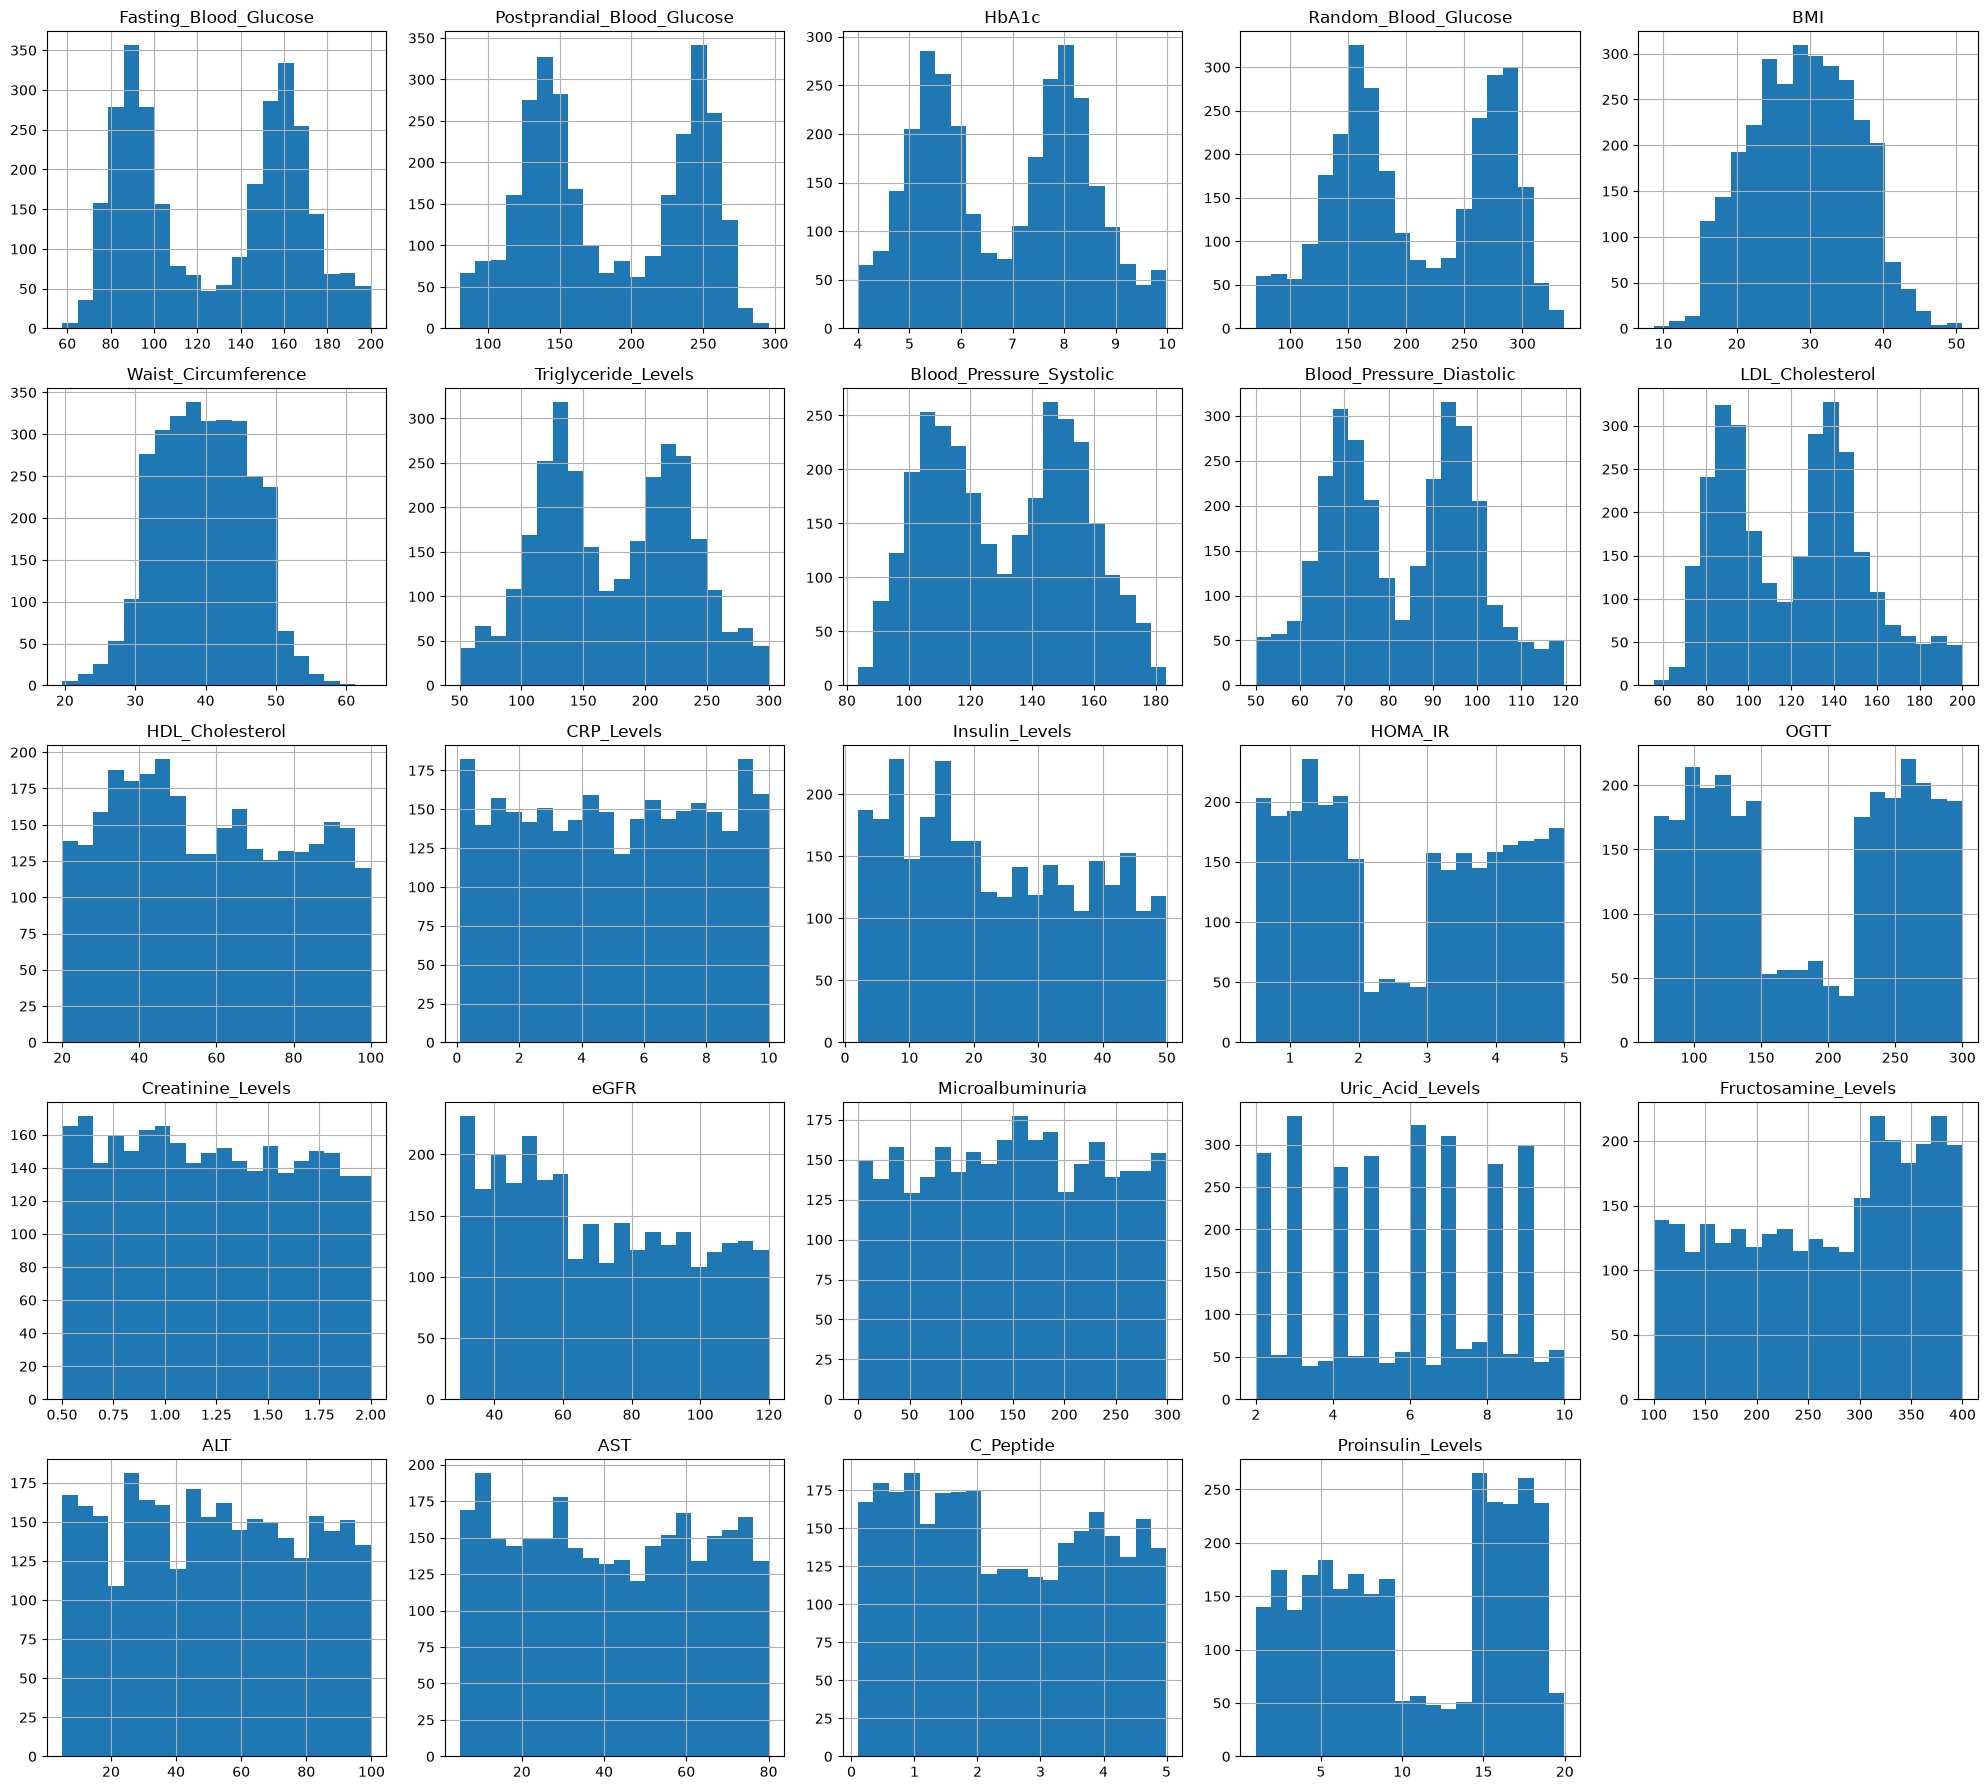

In [11]:
df.hist(figsize=(20, 18), bins=20)
plt.tight_layout()
plt.show()

In [12]:
# Separate features and target

X = df.drop(columns=["Diabetes_Status"])
y = df["Diabetes_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (3000, 34)
y shape: (3000,)

Target values:
Diabetes_Status
Positive    1664
Negative    1336
Name: count, dtype: int64


In [13]:
# Encode categorical Yes/No columns

categorical_features = X.select_dtypes(include="object").columns

print("Categorical features:")
print(categorical_features.tolist())

X[categorical_features] = X[categorical_features].replace({
    "Yes": 1,
    "No": 0
})

# Encode target
y = y.replace({
    "Positive": 1,
    "Negative": 0
})

print("\nEncoded X:")
print(X.head())

print("\nEncoded y:")
print(y.head())

Categorical features:
['Family_History_of_Diabetes', 'Gestational_Diabetes', 'PCOS', 'Hypertension', 'Physical_Activity', 'Smoking', 'Alcohol_Consumption', 'Obesity', 'Diet', 'Sleep_Apnea']

Encoded X:
   Fasting_Blood_Glucose  Postprandial_Blood_Glucose     HbA1c  \
0             118.690215                  111.472598  5.570234   
1             193.592860                  172.123161  5.481873   
2             165.159212                  228.400792  9.437527   
3             147.825603                  204.478231  5.497277   
4              90.282423                  217.115395  5.631698   

   Random_Blood_Glucose        BMI  Waist_Circumference  Triglyceride_Levels  \
0            224.721689  29.299897            37.872710           212.064239   
1            253.236721  35.135808            39.468713            93.096591   
2            127.607617  34.004023            47.090948           268.098641   
3            213.721043  18.847498            36.800088           203.279060   
4

C:\Users\sivas\AppData\Local\Temp\ipykernel_15324\1838624165.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[categorical_features] = X[categorical_features].replace({
C:\Users\sivas\AppData\Local\Temp\ipykernel_15324\1838624165.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({


In [14]:
print("Data types after encoding:")
print(X.dtypes)

print("\nNon-numeric columns:")
print(X.select_dtypes(exclude="number").columns.tolist())

Data types after encoding:
Fasting_Blood_Glucose         float64
Postprandial_Blood_Glucose    float64
HbA1c                         float64
Random_Blood_Glucose          float64
BMI                           float64
Waist_Circumference           float64
Triglyceride_Levels           float64
Blood_Pressure_Systolic       float64
Blood_Pressure_Diastolic      float64
LDL_Cholesterol               float64
HDL_Cholesterol               float64
CRP_Levels                    float64
Insulin_Levels                float64
HOMA_IR                       float64
OGTT                          float64
Creatinine_Levels             float64
eGFR                          float64
Microalbuminuria              float64
Uric_Acid_Levels              float64
Fructosamine_Levels           float64
ALT                           float64
AST                           float64
C_Peptide                     float64
Proinsulin_Levels             float64
Family_History_of_Diabetes      int64
Gestational_Diabetes   

In [15]:
print("\nX shape:", X.shape)
print("y shape:", y.shape)


X shape: (3000, 34)
y shape: (3000,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (2400, 34)
Testing data: (600, 34)

Training target distribution:
Diabetes_Status
1    1331
0    1069
Name: count, dtype: int64

Testing target distribution:
Diabetes_Status
1    333
0    267
Name: count, dtype: int64


In [17]:
# Import machine learning models and evaluation metrics

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("ML libraries imported successfully.")

ML libraries imported successfully.


In [18]:
# Train Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test)

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy  : 0.9250
Precision : 0.9337
Recall    : 0.9309
F1 Score  : 0.9323


C:\Users\sivas\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
# Train Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("-" * 35)
print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1 Score  : {dt_f1:.4f}")

Decision Tree Results
-----------------------------------
Accuracy  : 0.9033
Precision : 0.9056
Recall    : 0.9219
F1 Score  : 0.9137


In [20]:
# Train Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Calculate metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")

Random Forest Results
-----------------------------------
Accuracy  : 0.9267
Precision : 0.8981
Recall    : 0.9790
F1 Score  : 0.9368


In [21]:
# Train Support Vector Machine (SVM) model

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", SVC(
        kernel="rbf",
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test)

# Calculate metrics
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("-" * 35)
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")

C:\Users\sivas\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM Results
-----------------------------------
Accuracy  : 0.9383
Precision : 0.9405
Recall    : 0.9489
F1 Score  : 0.9447


In [22]:
# Train Gradient Boosting model

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gradient_boosting_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gradient_boosting_model.predict(X_test)

# Calculate metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-" * 35)
print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1 Score  : {gb_f1:.4f}")

Gradient Boosting Results
-----------------------------------
Accuracy  : 0.9300
Precision : 0.9217
Recall    : 0.9550
F1 Score  : 0.9381


In [23]:
# Compare all machine learning models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        svm_accuracy,
        gb_accuracy
    ],
    "Precision": [
        lr_precision,
        dt_precision,
        rf_precision,
        svm_precision,
        gb_precision
    ],
    "Recall": [
        lr_recall,
        dt_recall,
        rf_recall,
        svm_recall,
        gb_recall
    ],
    "F1 Score": [
        lr_f1,
        dt_f1,
        rf_f1,
        svm_f1,
        gb_f1
    ]
})

# Sort models by F1 Score
model_comparison = model_comparison.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

# Display results
display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.9383,0.9405,0.9489,0.9447
1,Gradient Boosting,0.9300,0.9217,0.9550,0.9381
2,Random Forest,0.9267,0.8981,0.9790,0.9368
3,Logistic Regression,0.9250,0.9337,0.9309,0.9323
4,Decision Tree,0.9033,0.9056,0.9219,0.9137


In [24]:
# Identify the best-performing model based on F1 Score

best_model_name = model_comparison.loc[
    model_comparison["F1 Score"].idxmax(), "Model"
]

best_f1_score = model_comparison["F1 Score"].max()

print("Best Model")
print("-" * 35)
print(f"Model    : {best_model_name}")
print(f"F1 Score : {best_f1_score:.4f}")

Best Model
-----------------------------------
Model    : SVM
F1 Score : 0.9447


In [25]:
# Select predictions from the best-performing model

if best_model_name == "Logistic Regression":
    best_predictions = y_pred_lr

elif best_model_name == "Decision Tree":
    best_predictions = y_pred_dt

elif best_model_name == "Random Forest":
    best_predictions = y_pred_rf

elif best_model_name == "SVM":
    best_predictions = y_pred_svm

elif best_model_name == "Gradient Boosting":
    best_predictions = y_pred_gb

else:
    raise ValueError("Best model not recognized")

print("Selected Best Model:", best_model_name)

Selected Best Model: SVM


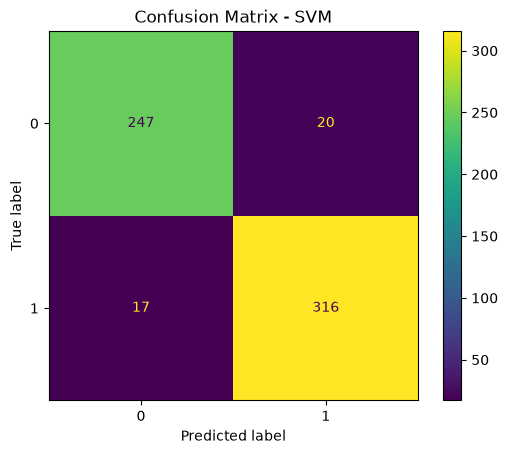

Classification Report - SVM
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       267
           1       0.94      0.95      0.94       333

    accuracy                           0.94       600
   macro avg       0.94      0.94      0.94       600
weighted avg       0.94      0.94      0.94       600



In [26]:
# Confusion Matrix for the Best Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, best_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

# Classification Report
print(f"Classification Report - {best_model_name}")
print("-" * 50)

print(
    classification_report(
        y_test,
        best_predictions
    )
)

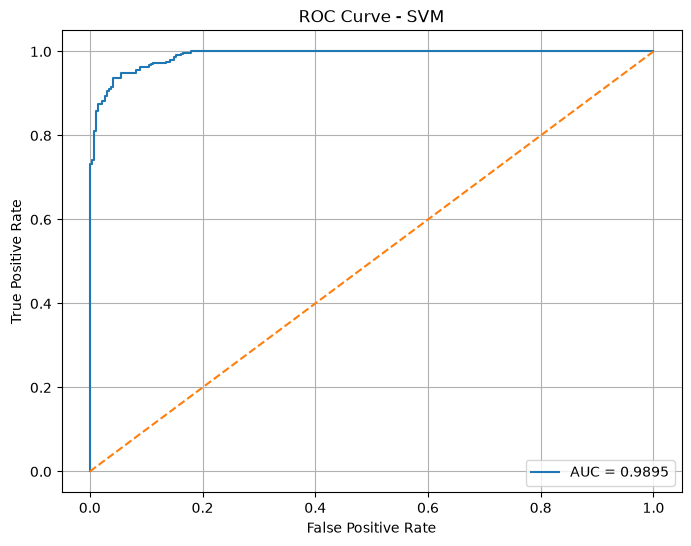

Best Model: SVM
AUC Score: 0.9895


In [27]:
# ROC Curve and AUC for the Best Model

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
if best_model_name == "Logistic Regression":
    best_probabilities = logistic_model.predict_proba(X_test)[:, 1]

elif best_model_name == "Decision Tree":
    best_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]

elif best_model_name == "Random Forest":
    best_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

elif best_model_name == "SVM":
    best_probabilities = svm_model.predict_proba(X_test)[:, 1]

elif best_model_name == "Gradient Boosting":
    best_probabilities = gradient_boosting_model.predict_proba(X_test)[:, 1]

# Calculate ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, best_probabilities)
auc_score = roc_auc_score(y_test, best_probabilities)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")
plt.legend()
plt.grid()
plt.show()

print(f"Best Model: {best_model_name}")
print(f"AUC Score: {auc_score:.4f}")

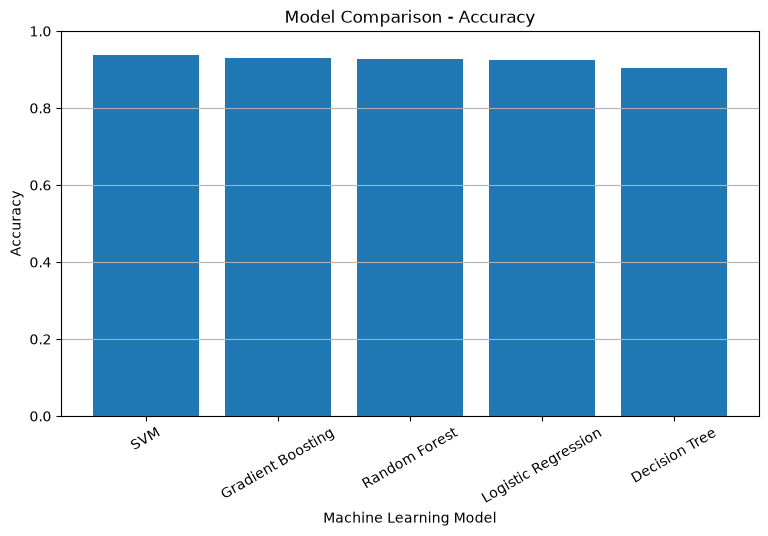

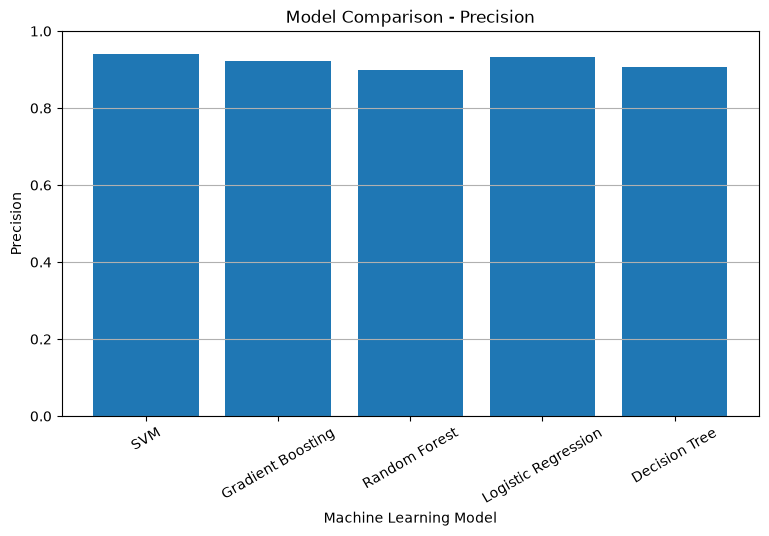

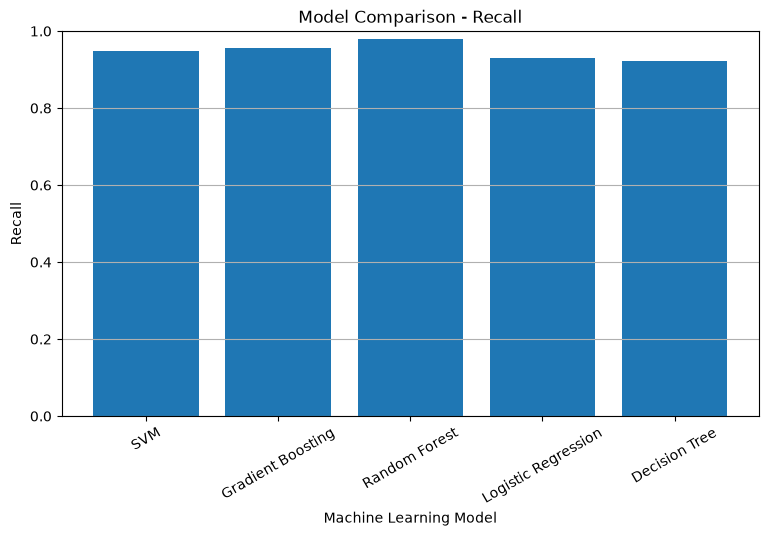

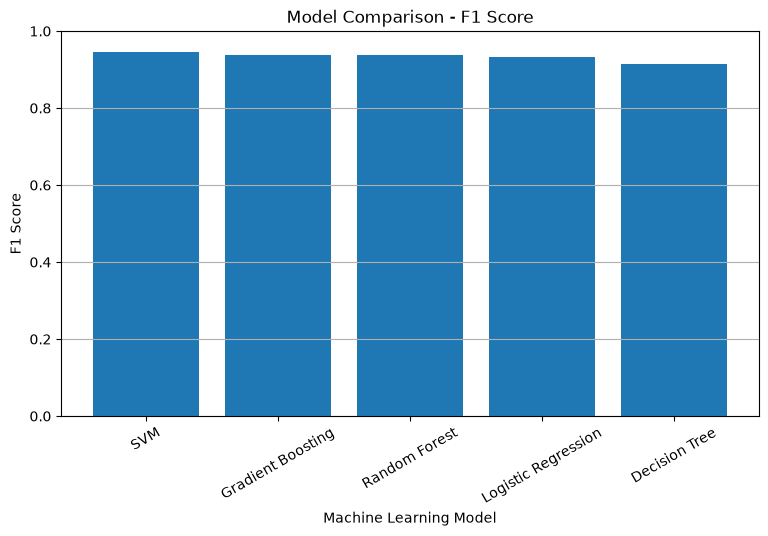

In [28]:
# Visualize model performance

import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

for metric in metrics:
    plt.figure(figsize=(9, 5))
    plt.bar(
        model_comparison["Model"],
        model_comparison[metric]
    )

    plt.xlabel("Machine Learning Model")
    plt.ylabel(metric)
    plt.title(f"Model Comparison - {metric}")
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.grid(axis="y")
    plt.show()

In [29]:
# Feature Importance of the Best Model

if best_model_name == "Random Forest":
    importance = random_forest_model.feature_importances_

elif best_model_name == "Decision Tree":
    importance = decision_tree_model.feature_importances_

elif best_model_name == "Gradient Boosting":
    importance = gradient_boosting_model.feature_importances_

else:
    importance = None

if importance is not None:

    feature_importance = pd.DataFrame({
        "Feature": X_train.columns,
        "Importance": importance
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(feature_importance)

    plt.figure(figsize=(9, 6))
    plt.barh(
        feature_importance["Feature"],
        feature_importance["Importance"]
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance - {best_model_name}")
    plt.gca().invert_yaxis()
    plt.show()

else:
    print(
        f"{best_model_name} does not provide direct feature importance."
    )

SVM does not provide direct feature importance.


In [30]:
# Save model comparison results

model_comparison.to_csv(
    "model_comparison_results.csv",
    index=False
)

# Save feature importance only if it was created
if "feature_importance" in globals():
    feature_importance.to_csv(
        "feature_importance_results.csv",
        index=False
    )
    print("Model comparison and feature importance saved successfully.")

else:
    print("Model comparison saved successfully.")
    print("Feature importance is not available for the selected best model.")

Model comparison saved successfully.
Feature importance is not available for the selected best model.


In [31]:
# SHAP Explainable AI

import shap
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

C:\Users\sivas\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.52.0


In [32]:
# Create SHAP Explainer for the Best Model

if best_model_name == "Random Forest":
    explainer = shap.TreeExplainer(random_forest_model)
    shap_values = explainer.shap_values(X_test)

elif best_model_name == "Decision Tree":
    explainer = shap.TreeExplainer(decision_tree_model)
    shap_values = explainer.shap_values(X_test)

elif best_model_name == "Gradient Boosting":
    explainer = shap.TreeExplainer(gradient_boosting_model)
    shap_values = explainer.shap_values(X_test)

elif best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(
        logistic_model,
        X_train
    )
    shap_values = explainer(X_test)

elif best_model_name == "SVM":
    # Use the underlying SVM classifier with scaled data

    scaler = svm_model.named_steps["scaler"]
    svm_classifier = svm_model.named_steps["classifier"]

    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    background = shap.sample(
        X_train_scaled,
        100,
        random_state=42
    )

    explainer = shap.KernelExplainer(
        svm_classifier.predict_proba,
        background
    )

    shap_values = explainer.shap_values(
        X_test_scaled[:100]
    )

else:
    raise ValueError("Best model not recognized")

print("SHAP explainer created successfully.")
print("Best Model:", best_model_name)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [34:41<00:00, 20.81s/it]

SHAP explainer created successfully.
Best Model: SVM


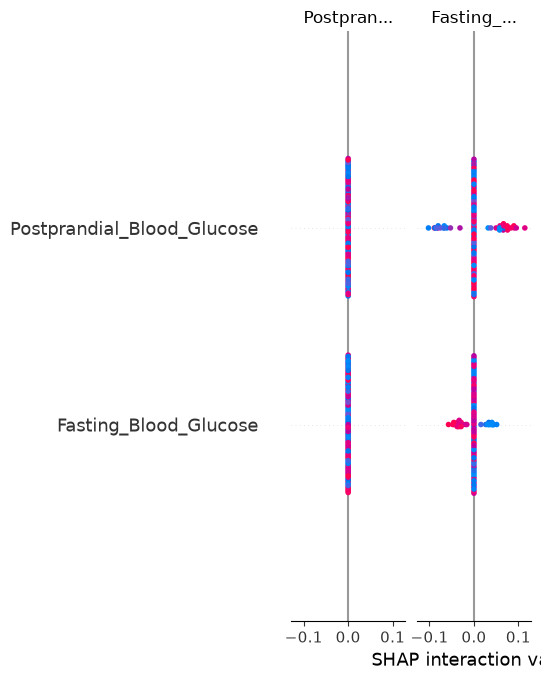

In [33]:
# SHAP Summary Plot

if isinstance(shap_values, list):
    if len(shap_values) > 1:
        shap_values_plot = shap_values[1]
    else:
        shap_values_plot = shap_values[0]
else:
    shap_values_plot = shap_values

shap.summary_plot(
    shap_values_plot,
    X_test_scaled[:100],
    feature_names=X_test.columns,
    show=True
)

In [34]:
# Save SHAP Feature Importance

shap_array = np.array(shap_values_plot)

print("SHAP values shape:", shap_array.shape)

# Handle extra dimensions from SHAP output
if shap_array.ndim == 3:
    shap_array = shap_array[:, :, 0]

shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_Absolute_SHAP": np.abs(shap_array).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance)

shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")

SHAP values shape: (100, 34, 2)


,Feature,Mean_Absolute_SHAP
0,Insulin_Levels,0.046096
1,Fructosamine_Levels,0.042403
2,AST,0.040450
3,HOMA_IR,0.040243
4,Proinsulin_Levels,0.035284
5,Family_History_of_Diabetes,0.033354
6,ALT,0.033274
7,Uric_Acid_Levels,0.031498
8,C_Peptide,0.027370
9,Creatinine_Levels,0.027232


SHAP feature importance saved successfully.


In [35]:
import joblib

# Save the best model
joblib.dump(svm_model, "diabetes_best_model.pkl")

print("Best model saved successfully.")
print("Model: SVM")
print("File: diabetes_best_model.pkl")

Best model saved successfully.
Model: SVM
File: diabetes_best_model.pkl


In [36]:
# Load the saved best model

loaded_model = joblib.load("diabetes_best_model.pkl")

# Test prediction using the test dataset
test_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Model loaded successfully.")
print("Predicted Class:", test_prediction[0])
print("Actual Class:", y_test.iloc[0])

Model loaded successfully.
Predicted Class: 1
Actual Class: 1


In [37]:
# Patient Diabetes Prediction Function

def predict_diabetes(patient_data):
    
    # Convert patient input into DataFrame
    patient_df = pd.DataFrame(
        [patient_data],
        columns=X_train.columns
    )
    
    # Make prediction
    prediction = loaded_model.predict(patient_df)[0]
    
    # Get prediction probability
    probability = loaded_model.predict_proba(patient_df)[0]
    
    return prediction, probability


print("Patient prediction function created successfully.")

Patient prediction function created successfully.


In [38]:
# Test the CDSS prediction with one patient from the test dataset

sample_patient = X_test.iloc[0].to_dict()

prediction, probability = predict_diabetes(sample_patient)

print("Patient Prediction")
print("-" * 40)
print("Predicted Class:", prediction)
print("Prediction Probability:", probability)
print("Actual Class:", y_test.iloc[0])

Patient Prediction
----------------------------------------
Predicted Class: 1
Prediction Probability: [5.66563964e-06 9.99994334e-01]
Actual Class: 1


In [39]:
# Display prediction in a more understandable format

prediction, probability = predict_diabetes(sample_patient)

predicted_probability = max(probability) * 100

print("DIABETES CDSS RESULT")
print("=" * 40)
print(f"Predicted Class      : {prediction}")
print(f"Confidence           : {predicted_probability:.2f}%")
print(f"Actual Class         : {y_test.iloc[0]}")

DIABETES CDSS RESULT
Predicted Class      : 1
Confidence           : 100.00%
Actual Class         : 1


In [40]:
# Complete CDSS prediction function

def cdss_predict(patient_data):
    
    patient_df = pd.DataFrame(
        [patient_data],
        columns=X_train.columns
    )
    
    prediction = loaded_model.predict(patient_df)[0]
    probabilities = loaded_model.predict_proba(patient_df)[0]
    confidence = max(probabilities) * 100
    
    result = {
        "Predicted Class": prediction,
        "Confidence": round(confidence, 2)
    }
    
    return result


print("CDSS prediction system ready.")

CDSS prediction system ready.


In [41]:
# Test complete CDSS

result = cdss_predict(sample_patient)

print("CDSS PREDICTION")
print("-" * 40)
print("Predicted Class:", result["Predicted Class"])
print("Confidence:", str(result["Confidence"]) + "%")

CDSS PREDICTION
----------------------------------------
Predicted Class: 1
Confidence: 100.0%


In [42]:
# Final model performance summary

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1,
        auc_score
    ]
})

display(final_results.round(4))

,Metric,Score
0,Accuracy,0.9383
1,Precision,0.9405
2,Recall,0.9489
3,F1 Score,0.9447
4,ROC-AUC,0.9895


In [43]:
# Save all important CDSS results

model_comparison.to_csv(
    "model_comparison_results.csv",
    index=False
)

shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

final_results.to_csv(
    "final_model_performance.csv",
    index=False
)

print("All important project results saved successfully.")

All important project results saved successfully.


In [44]:
# Save feature names used by the model

feature_names = pd.DataFrame({
    "Feature": X_train.columns
})

feature_names.to_csv(
    "model_features.csv",
    index=False
)

print("Model feature list saved successfully.")
print("\nFeatures used by the model:")
for feature in X_train.columns:
    print("-", feature)

Model feature list saved successfully.

Features used by the model:
- Fasting_Blood_Glucose
- Postprandial_Blood_Glucose
- HbA1c
- Random_Blood_Glucose
- BMI
- Waist_Circumference
- Triglyceride_Levels
- Blood_Pressure_Systolic
- Blood_Pressure_Diastolic
- LDL_Cholesterol
- HDL_Cholesterol
- CRP_Levels
- Insulin_Levels
- HOMA_IR
- OGTT
- Creatinine_Levels
- eGFR
- Microalbuminuria
- Uric_Acid_Levels
- Fructosamine_Levels
- ALT
- AST
- C_Peptide
- Proinsulin_Levels
- Family_History_of_Diabetes
- Gestational_Diabetes
- PCOS
- Hypertension
- Physical_Activity
- Smoking
- Alcohol_Consumption
- Obesity
- Diet
- Sleep_Apnea


In [45]:
# Final CDSS Project Summary

print("=" * 60)
print("DIABETES CLINICAL DECISION SUPPORT SYSTEM")
print("=" * 60)

print("\nMachine Learning Models Evaluated:")
for model in model_comparison["Model"]:
    print("-", model)

print("\nBest Model:")
print("-", best_model_name)

print("\nPerformance:")
print(f"- Accuracy  : {svm_accuracy:.4f}")
print(f"- Precision : {svm_precision:.4f}")
print(f"- Recall    : {svm_recall:.4f}")
print(f"- F1 Score : {svm_f1:.4f}")
print(f"- ROC-AUC   : {auc_score:.4f}")

print("\nExplainable AI:")
print("- SHAP analysis completed")

print("\nSaved Files:")
print("- diabetes_best_model.pkl")
print("- model_comparison_results.csv")
print("- final_model_performance.csv")
print("- shap_feature_importance.csv")
print("- model_features.csv")

print("\nCDSS ML pipeline completed successfully.")

DIABETES CLINICAL DECISION SUPPORT SYSTEM

Machine Learning Models Evaluated:
- SVM
- Gradient Boosting
- Random Forest
- Logistic Regression
- Decision Tree

Best Model:
- SVM

Performance:
- Accuracy  : 0.9383
- Precision : 0.9405
- Recall    : 0.9489
- F1 Score : 0.9447
- ROC-AUC   : 0.9895

Explainable AI:
- SHAP analysis completed

Saved Files:
- diabetes_best_model.pkl
- model_comparison_results.csv
- final_model_performance.csv
- shap_feature_importance.csv
- model_features.csv

CDSS ML pipeline completed successfully.


In [46]:
# SHAP - Check existing variables and shapes

print("X_test shape:", X_test.shape)

if 'shap_values_plot' in globals():
    print("shap_values_plot shape:", np.array(shap_values_plot).shape)
else:
    print("shap_values_plot is not defined")

if 'explainer' in globals():
    print("Explainer exists:", type(explainer).__name__)
else:
    print("Explainer is not defined")

print("Best model:", best_model_name if 'best_model_name' in globals() else "Not defined")

X_test shape: (600, 34)
shap_values_plot shape: (100, 34, 2)
Explainer exists: KernelExplainer
Best model: SVM


In [47]:
# Check the existing SHAP values

print("X_test shape:", X_test.shape)

print("SHAP values type:", type(shap_values_plot))
print("SHAP values shape:", np.array(shap_values_plot).shape)

print("Number of features:", X_test.shape[1])
print("Number of feature names:", len(X_test.columns))

X_test shape: (600, 34)
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (100, 34, 2)
Number of features: 34
Number of feature names: 34
